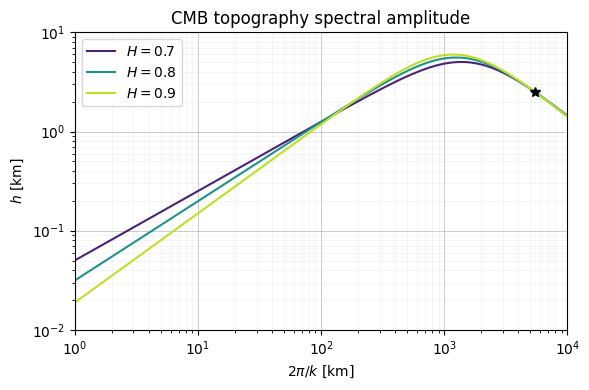

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import gamma

# Physical constants (SI)
rho   = 11e3             # kg/m^3
U0    = 8.7e-5           # m/s
Omega = 2 * np.pi / 86400  # rad/s
R     = 3485e3           # m
kobs  = 4.0 / R          # m^-1
hobs  = 2.5e3            # m

def solve_k0_hrms(H):
    """
    Substituting constraint 2 (spectral normalisation at kobs) into
    constraint 1 (nutation target) gives a single equation in k0:

      A(H) * k0^3 * (1 + kobs^2/k0^2)^(1+H) = 5e-8
      A(H) = C1(H) * hobs^2 / (2H * kobs^2)

    This function has a minimum at k0_min = kobs*sqrt((2H-1)/3).
    The physical root (lam0 ~ few 1000 km) lies on the right branch
    (k0 > k0_min), bracketed between k0_min and a large k0.
    """
    C1 = 3 * rho * U0**2 * Omega * gamma(H - 0.5) / (16 * np.pi**2.5 * gamma(H))
    A  = C1 * hobs**2 / (2 * H * kobs**2)

    def equation(k0):
        return A * k0**3 * (1 + kobs**2 / k0**2)**(1 + H) - 5e-8

    k0_min = kobs * np.sqrt((2 * H - 1) / 3)  # location of the function minimum
    k0_sol = brentq(equation, k0_min * 1.001, 1e-2)
    hrms_sol = hobs * k0_sol * (1 + kobs**2 / k0_sol**2)**((1 + H) / 2) / (np.sqrt(2 * H) * kobs)
    return k0_sol, hrms_sol

# Wavelength array (km)
lam = np.logspace(0, 4, 1000)
lam_obs = (2 * np.pi / kobs) / 1e3  # observed wavelength in km

H_values = [0.7, 0.8, 0.9]
colors = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.9, len(H_values))]

fig, ax = plt.subplots(figsize=(6, 4))

for H, color in zip(H_values, colors):
    k0_si, hrms_si = solve_k0_hrms(H)
    lam0 = (2 * np.pi / k0_si) / 1e3  # m -> km
    hrms = hrms_si / 1e3               # m -> km
    h = np.sqrt(2 * hrms**2 * H * lam0**2) / lam * (1 + lam0**2 / lam**2)**(-(H + 1) / 2)
    ax.loglog(lam, h, '-', color=color, linewidth=1.5, label=f'$H = {H}$')

# # Curve from Monville et al. (2025) (values already in km)
# hrms_ref = 1.82334806718919
# k0_ref   = 0.0006398824526416522  # km^-1
# lam0_ref = 2 * np.pi / k0_ref     # km
# H_ref    = 1.3662725358363954
# h_ref = np.sqrt(2 * hrms_ref**2 * H_ref * lam0_ref**2) / lam * (1 + lam0_ref**2 / lam**2)**(-(H_ref + 1) / 2)
# ax.loglog(lam, h_ref, 'k--', linewidth=1.5, label='Monville et al. (2025)')

# Star marker at the common anchoring point (lambda_obs, h_obs)
ax.plot(lam_obs, hobs / 1e3, '*', color='black', markersize=7, zorder=5)

ax.set_title(r'CMB topography spectral amplitude')
ax.set_xlabel(r'$2\pi/k$ [km]')
ax.set_ylabel(r'$h$ [km]')
ax.set_xlim(1, 10000)
ax.set_ylim(1e-2, 10)
ax.grid(which='major', color='black', alpha=0.2, linewidth=0.7)
ax.grid(which='minor', color='black', alpha=0.08, linewidth=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('h_lambda.pdf')
plt.show()
